# Calculate mAP scores comparing the compounds at an MOA level to the control (DMSO)

In [1]:
import os
import pathlib

import numpy as np
import pandas as pd
from copairs import map  # noqa: A004
from copairs.matching import assign_reference_index
from plotnine import (
    aes,
    element_blank,
    element_text,
    facet_wrap,
    geom_abline,
    geom_bar,
    geom_hline,
    geom_line,
    geom_point,
    geom_text,
    ggplot,
    labs,
    scale_color_gradientn,
    scale_fill_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from scipy.stats import mannwhitneyu


## Helper functions

In [2]:
# Perform mean average precision calculation
def compute_activity_ap(
    treatment_df: pd.DataFrame,
    pos_sameby: list,
    pos_diffby: list,
    neg_sameby: list,
    neg_diffby: list,
) -> pd.DataFrame:
    """Compute per-profile average precision (AP) for one compound/dose group.

    Args:
        treatment_df (pd.DataFrame): Rows for a single compound/dose group plus
            the DMSO wells it should be compared against.
        pos_sameby (list): Positive samples to compare.
        pos_diffby (list): Positive samples to compare.
        neg_sameby (list): Negative samples to compare.
        neg_diffby (list): Negative samples to compare.

    Returns:
        pd.DataFrame: Per-profile AP scores (DMSO query rows dropped).
    """
    metadata = treatment_df.filter(regex="^Metadata")
    profiles = treatment_df.filter(regex="^(?!Metadata)").values

    activity_ap = map.average_precision(
        metadata, profiles, pos_sameby, pos_diffby, neg_sameby, neg_diffby
    )
    return activity_ap.query("Metadata_broad_sample != 'DMSO'")


def compute_map_scores(  # noqa: PLR0913
    df_activity: pd.DataFrame,
    pos_sameby: list,
    pos_diffby: list,
    neg_sameby: list,
    neg_diffby: list,
    min_replicates: int,
    seed: int = 0,
) -> pd.DataFrame:
    """Calculate mAP scores for every compound/dose group vs. its own on-plate DMSO wells.

    Each compound/dose group is compared only to the DMSO wells living on the
    specific plate(s) that group's own replicates were run on.

    AP is computed separately per compound/dose group, since each group has
    its own comparison pool of DMSO wells, but all resulting AP scores are
    concatenated and passed through `map.mean_average_precision` (p-values,
    FDR correction) ONCE across the full batch.

    Args:
        df_activity (pd.DataFrame): Activity data with reference index assigned.
        pos_sameby (list): Positive samples to compare.
        pos_diffby (list): Positive samples to compare.
        neg_sameby (list): Negative samples to compare.
        neg_diffby (list): Negative samples to compare.
        min_replicates (int): Minimum replicate wells (and minimum distinct
            plates) required per compound/dose group for positive pairing.
        seed (int, optional): Random seed for the null distribution. Defaults to 0.

    Returns:
        pd.DataFrame: One row per compound/dose group with mAP scores, p-values,
            and average proportion of failed single cells.
    """
    non_dmso = df_activity[df_activity["Metadata_broad_sample"] != "DMSO"]

    list_of_ap = []
    failed_prop_records = []
    for (treatment, dose), group_df in non_dmso.groupby(
        ["Metadata_broad_sample", "Metadata_dose_recode"]
    ):
        dose_plates = group_df["Metadata_Plate"].unique()
        unique_pos_diffby = group_df[pos_diffby].drop_duplicates()
        if (
            group_df.shape[0] < min_replicates
            or unique_pos_diffby.shape[0] < min_replicates
        ):
            print(
                f"Skipping {treatment} (dose {dose}): not enough replicates or "
                f"not enough unique '{pos_diffby}' values for positive pairs."
            )
            continue

        # Compare this compound/dose group only to DMSO wells from the same
        # plate(s) its own replicates were run on
        treatment_df = df_activity[
            (
                (df_activity["Metadata_broad_sample"] == treatment)
                & (df_activity["Metadata_dose_recode"] == dose)
            )
            | (
                (df_activity["Metadata_broad_sample"] == "DMSO")
                & (df_activity["Metadata_Plate"].isin(dose_plates))
            )
        ]

        list_of_ap.append(
            compute_activity_ap(
                treatment_df, pos_sameby, pos_diffby, neg_sameby, neg_diffby
            )
        )
        failed_prop_records.append(
            {
                "Metadata_broad_sample": treatment,
                "Metadata_dose_recode": dose,
                "Metadata_avg_prop_failed_single_cells": (
                    group_df["Metadata_sc_count_failed_qc"]
                    / group_df["Metadata_sc_count"]
                ).mean(),
            }
        )

    all_ap = pd.concat(list_of_ap, ignore_index=True)
    activity_map = map.mean_average_precision(
        all_ap, pos_sameby, seed=seed, null_size=10000, threshold=0.05
    )
    activity_map["-log10(p-value)"] = -activity_map["corrected_p_value"].apply(np.log10)

    return activity_map.merge(
        pd.DataFrame(failed_prop_records),
        on=["Metadata_broad_sample", "Metadata_dose_recode"],
        how="left",
    )


# Calculate proportion of points above, below, and equal to y=x per dose
def proportion_above_below_y_eq_x(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate the proportion of points above, below, and equal to the y=x line.

    Args:
        df (pd.DataFrame): DataFrame containing the activity data.

    Returns:
        pd.DataFrame: Dataframe with proportions and counts per dose.
    """
    results = []
    for dose, group in df.groupby("Metadata_dose_recode"):
        above = (
            group["mean_average_precision_postQC"]
            > group["mean_average_precision_preQC"]
        ).sum()
        below = (
            group["mean_average_precision_postQC"]
            < group["mean_average_precision_preQC"]
        ).sum()
        equal = (
            group["mean_average_precision_postQC"]
            == group["mean_average_precision_preQC"]
        ).sum()
        total = len(group)
        results.append(
            {
                "Metadata_dose_recode": dose,
                "proportion_above": above / total if total > 0 else np.nan,
                "proportion_below": below / total if total > 0 else np.nan,
                "proportion_equal": equal / total if total > 0 else np.nan,
                "n_points": total,
            }
        )
    return pd.DataFrame(results)


def calculate_replicate_cosine_similarity(
    activity_df: pd.DataFrame,
    group_cols: list[str] | None = None,
    exclude_profile_cols: list[str] | None = None,
    min_replicates: int = 2,
) -> pd.DataFrame:
    """Calculate pairwise replicate cosine similarity for all treatment groups.

    The returned rows are one compound-dose (or general group) each. The mean summarizes all
    pairwise cosine similarities among replicate profiles in that group.

    This function measures within-group reproducibility of feature profiles
    (e.g., compounds, doses, and DMSO controls) by computing cosine similarity
    between replicate feature vectors in a shared feature space.

    Args:
        activity_df (pd.DataFrame): DataFrame containing activity data with metadata and
            profile columns (feature space used for cosine similarity).
        group_cols (list[str], optional): List of metadata columns to group by. Defaults
            to ["Metadata_broad_sample", "Metadata_dose_recode"].
        exclude_profile_cols (list[str], optional): List of numeric columns to exclude
            from profile data (e.g., "failed_proportion").
            Defaults to ["failed_proportion"].
        min_replicates (int, optional): Minimum number of replicates required to
            calculate cosine similarity. Defaults to 2.

    Returns:
        pd.DataFrame: DataFrame with group columns and summary statistics of
            pairwise cosine similarity for each treatment group.
    """
    # Set default columns if not provided
    if group_cols is None:
        group_cols = ["Metadata_broad_sample", "Metadata_dose_recode"]
    if exclude_profile_cols is None:
        exclude_profile_cols = ["failed_proportion"]

    # Use full dataset (no external filtering / map restriction)
    activity_subset = activity_df.copy()

    # Identify profile columns by excluding metadata and specified columns
    metadata_cols = activity_subset.filter(regex="^Metadata").columns
    numeric_cols = activity_subset.select_dtypes(include="number").columns
    profile_cols = [
        col
        for col in numeric_cols
        if col not in metadata_cols and col not in exclude_profile_cols
    ]

    # Calculate pairwise cosine similarity for each group and store results
    results = []
    for group_values, group_df in activity_subset.groupby(group_cols, dropna=False):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        # Extract profile data and handle NaN values by replacing them with zeros
        profiles = group_df[profile_cols].to_numpy(dtype=float)
        profiles = np.nan_to_num(profiles, nan=0.0, posinf=0.0, neginf=0.0)

        # Skip groups with fewer than the minimum number of replicates
        if profiles.shape[0] < min_replicates:
            continue

        # Ensure proper cosine similarity even if upstream normalization drifted
        norms = np.linalg.norm(profiles, axis=1, keepdims=True)
        profiles = np.divide(
            profiles, norms, out=np.zeros_like(profiles), where=norms != 0
        )

        cosine_matrix = profiles @ profiles.T

        # Extract upper triangle (excluding diagonal)
        pair_indices = np.triu_indices(profiles.shape[0], k=1)
        pairwise_cosine = cosine_matrix[pair_indices]

        # Store results with group values and summary statistics
        results.append(
            {
                **dict(zip(group_cols, group_values, strict=True)),
                "n_replicates": profiles.shape[0],
                "n_pairwise_comparisons": pairwise_cosine.size,
                "mean_pairwise_cosine_similarity": pairwise_cosine.mean(),
                "median_pairwise_cosine_similarity": np.median(pairwise_cosine),
                "std_pairwise_cosine_similarity": (
                    pairwise_cosine.std(ddof=1) if pairwise_cosine.size > 1 else 0.0
                ),
            }
        )

    return pd.DataFrame(results)


## Load in the data for pre and post QC

In [3]:
MIN_REPLICATES = 2  # Minimum number of replicates required

# Input path for single-cell profiles
input_dir = pathlib.Path(
    "/home/jenna/mnt/bandicoot/LINCS_data/processed_profiles/single_cell_profiles"
)

# Output path for merged profiles
output_dir = pathlib.Path("./mAP_results")
output_dir.mkdir(parents=True, exist_ok=True)

# Load cell painting profiles (pre-QC)
pre_qc_file = pathlib.Path(input_dir, "whole_batch_pre_qc_cpd_replicates.parquet")
pre_qc_df = pd.read_parquet(pre_qc_file)
pre_qc_df = pre_qc_df.drop(columns=["broad_id", "pert_iname", "moa", "replicate_name"])

# Load cell painting profiles (post-QC)
post_qc_file = pathlib.Path(input_dir, "whole_batch_post_qc_cpd_replicates.parquet")
post_qc_df = pd.read_parquet(post_qc_file)
post_qc_df = post_qc_df.drop(
    columns=["broad_id", "pert_iname", "moa", "replicate_name"]
)
post_qc_df["Metadata_sc_count_failed_qc"] = post_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

# Align "Metadata_sc_count_failed_qc" from post-QC df to pre-QC df using
# Metadata_Plate and Metadata_Well
pre_qc_df = pre_qc_df.merge(
    post_qc_df[["Metadata_Plate", "Metadata_Well", "Metadata_sc_count_failed_qc"]],
    on=["Metadata_Plate", "Metadata_Well"],
    how="left",
    suffixes=("", "_postqc"),
)
pre_qc_df["Metadata_sc_count_failed_qc"] = pre_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)


In [4]:
# Compute percentage of failed QC single-cell across all plates in post_qc_df
total_failed = post_qc_df["Metadata_sc_count_failed_qc"].sum()
total_cells = post_qc_df["Metadata_sc_count"].sum()
failed_qc_percentage = (total_failed / total_cells) * 100
print(
    f"Percentage of failed QC single-cell across all plates: "
    f"{failed_qc_percentage:.2f}%"
)


Percentage of failed QC single-cell across all plates: 29.03%


In [5]:
# Calculate proportion of failed cells for each well
post_qc_df["failed_proportion"] = post_qc_df["Metadata_sc_count_failed_qc"] / (
    post_qc_df["Metadata_sc_count_failed_qc"]
    + post_qc_df["Metadata_sc_count_passed_qc"]
)

# Compare failed proportions between compounds and DMSO
compound_failed = post_qc_df.loc[
    post_qc_df["Metadata_broad_sample"] != "DMSO", "failed_proportion"
]
dmso_failed = post_qc_df.loc[
    post_qc_df["Metadata_broad_sample"] == "DMSO", "failed_proportion"
]

# Print mean failed proportions
print(f"Mean failed proportion (compounds): {compound_failed.mean():.4f}")
print(f"Mean failed proportion (DMSO): {dmso_failed.mean():.4f}")


Mean failed proportion (compounds): 0.3019
Mean failed proportion (DMSO): 0.2970


## Assign reference index

In [6]:
reference_col = "Metadata_reference_index"

pre_qc_df_activity = assign_reference_index(
    pre_qc_df,
    "Metadata_broad_sample == 'DMSO'",  # condition to get reference profiles
    reference_col=reference_col,
    default_value=-1,
)

post_qc_df_activity = assign_reference_index(
    post_qc_df,
    "Metadata_broad_sample == 'DMSO'",  # condition to get reference profiles
    reference_col=reference_col,
    default_value=-1,
)


## Set positive and negative pairs for compounds

In [7]:
# positive pairs are replicates of the same treatment
pos_sameby = ["Metadata_broad_sample", "Metadata_dose_recode", reference_col]
pos_diffby = ["Metadata_Plate"]

# negative pairs are replicates of different treatments
neg_sameby = []  # set plate if you don't want to compare controls across all plates
neg_diffby = ["Metadata_broad_sample", reference_col]


## Calculate mAP scores per treatment compared to controls for both pre- and post-QC

### Pre-QC dataframe

In [8]:
preqc_map_file = f"{output_dir}/final_map_scores_preQC.parquet"
if os.path.exists(preqc_map_file):
    final_map_preQC = pd.read_parquet(preqc_map_file)
    print("Loaded preQC mAP results from file.")
else:
    final_map_preQC = compute_map_scores(
        pre_qc_df_activity,
        pos_sameby,
        pos_diffby,
        neg_sameby,
        neg_diffby,
        MIN_REPLICATES,
    )
    final_map_preQC["QC_status"] = "pre-QC"
    # Save final mAP results to file
    final_map_preQC.to_parquet(preqc_map_file, index=False)


Loaded preQC mAP results from file.


### Post-QC dataframe

In [9]:
postqc_map_file = f"{output_dir}/final_map_scores_postQC.parquet"
if os.path.exists(postqc_map_file):
    final_map_postQC = pd.read_parquet(postqc_map_file)
    print("Loaded postQC mAP results from file.")
else:
    final_map_postQC = compute_map_scores(
        post_qc_df_activity,
        pos_sameby,
        pos_diffby,
        neg_sameby,
        neg_diffby,
        MIN_REPLICATES,
    )
    final_map_postQC["QC_status"] = "post-QC"
    # Save final mAP results to file
    final_map_postQC.to_parquet(postqc_map_file, index=False)


Loaded postQC mAP results from file.


## Merge pre-QC and post-QC results

In [10]:
# Merge preQC and postQC results on sample and dose
merged_map = pd.merge(
    final_map_preQC,
    final_map_postQC,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    suffixes=("_preQC", "_postQC"),
)

# Compute change per row
merged_map["mAP_change"] = (
    merged_map["mean_average_precision_postQC"]
    - merged_map["mean_average_precision_preQC"]
)

# Filter rows where the preQC was low and the change was large
improved_rows = merged_map.query(
    "mean_average_precision_preQC <= 0.5 and mAP_change >= 0.2"
)

# Count unique compounds
num_improved = improved_rows["Metadata_broad_sample"].nunique()

# Compute percentage of all rows (compounds and doses) that improved
percent_improved = len(improved_rows) / len(merged_map) * 100

print(f"{num_improved} compounds with preQC ≤ 0.5 and an increase ≥ 0.2.")
print(f"These rows represent {percent_improved:.1f}% of all compounds/doses.")


20 compounds with preQC ≤ 0.5 and an increase ≥ 0.2.
These rows represent 0.2% of all compounds/doses.


## Generate plot of mAP scores pre= and post-QC

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 4 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/mAP_preQC_vs_postQC_by_dose.png


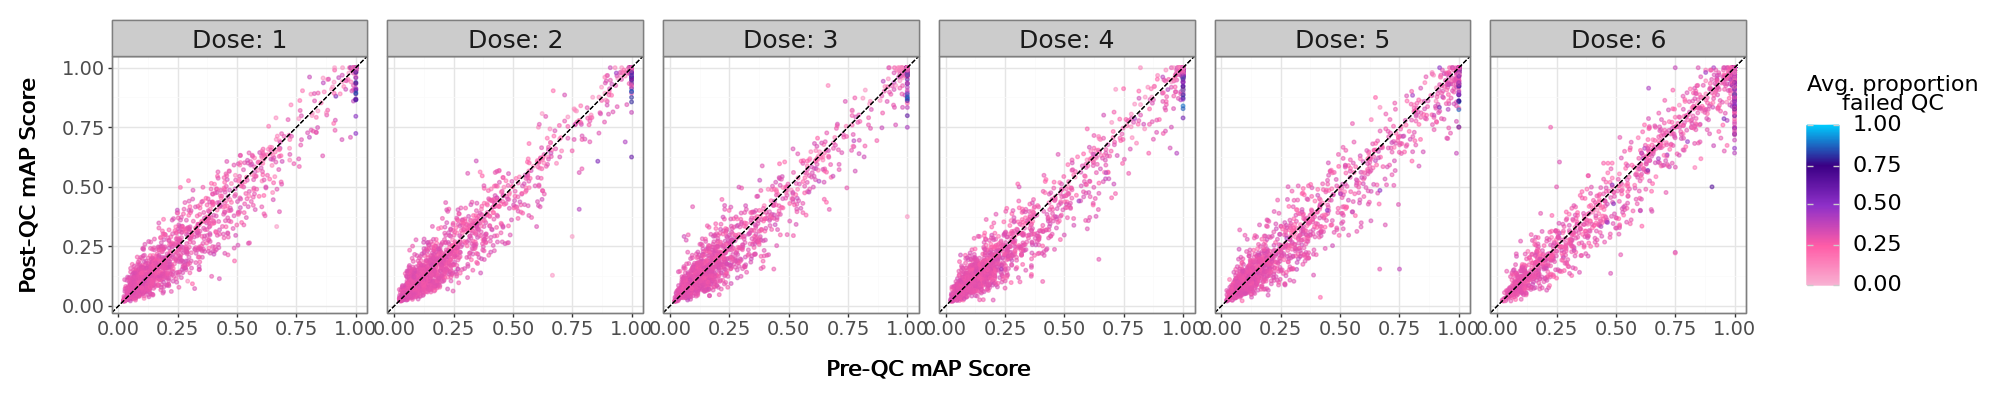

In [11]:
# Drop dose 0 and 7 due to small number of samples
merged_map = merged_map.query("Metadata_dose_recode not in [0, 7]")

# Set the figure size
height = 4
width = 20
set_option("figure_size", (width, height))

# Define the custom coSMic QC palette (lighter pink to purple to cyan)
cosmicqc_palette = [
    "#f8b3d3",  # Light pink
    "#ff5ca7",  # Vibrant pink
    "#8f30c9",  # Medium purple
    "#3b0085",  # Deep purple
    "#00cafd",  # Cyan accent
]

# Make the plotnine plot
p = (
    ggplot(
        merged_map,
        aes(
            x="mean_average_precision_preQC",
            y="mean_average_precision_postQC",
            color="Metadata_avg_prop_failed_single_cells_postQC", # pre-QC and post-QC are the same
        ),
    )
    + geom_point(alpha=0.3, size=1.0)
    + geom_abline(slope=1, intercept=0, linetype="dashed", color="black", size=0.5)
    + facet_wrap(
        "~Metadata_dose_recode", nrow=1, labeller=lambda x: f"Dose: {x}"
    )
    + scale_color_gradientn(
        name="Avg. proportion\nfailed QC",
        colors=cosmicqc_palette,
        limits=(0, 1),
    )
    + labs(
        x="Pre-QC mAP Score",
        y="Post-QC mAP Score",
    )
    + theme_bw()
    + theme(
        legend_position="right",
        axis_title=element_text(size=16),
        axis_text=element_text(size=14),
        legend_title=element_text(size=16),
        legend_text=element_text(size=16),
        strip_text=element_text(size=18),
    )
)

# Save as PNG
p.save("figures/mAP_preQC_vs_postQC_by_dose.png", dpi=400)
fig = p.draw()

for ax in fig.axes:
    # rasterize scatter points only
    for coll in ax.collections:
        coll.set_rasterized(True)
    # keep lines and legend as vectors

# Save as SVG
fig.savefig("figures/mAP_preQC_vs_postQC_by_dose.svg", dpi=400)

# To show the plot:
p.show()


# Determine the proportion above and below the line

In [12]:
# Get proportion of points above and below y=x line
proportion_df = proportion_above_below_y_eq_x(merged_map)
proportion_df


,Metadata_dose_recode,proportion_above,proportion_below,proportion_equal,n_points
0,1,0.422508,0.529904,0.047588,1555
1,2,0.417363,0.520257,0.062379,1555
2,3,0.408360,0.495177,0.096463,1555
3,4,0.346624,0.533119,0.120257,1555
4,5,0.344093,0.535184,0.120723,1549
5,6,0.262783,0.506149,0.231068,1545


## Calculate average cosine similarity across well-replicates per compound and dose

In [13]:
# Compute replicate cosine similarity for pre-QC and post-QC datasets
replicate_cosine_preQC = calculate_replicate_cosine_similarity(
    pre_qc_df_activity
).add_suffix("_preQC")

replicate_cosine_postQC = calculate_replicate_cosine_similarity(
    post_qc_df_activity
).add_suffix("_postQC")

# Output replicate cosine similarity results to file
replicate_cosine_preQC.to_parquet(
    output_dir / "replicate_pairwise_cosine_similarity_preQC.parquet",
    index=False,
)

replicate_cosine_postQC.to_parquet(
    output_dir / "replicate_pairwise_cosine_similarity_postQC.parquet",
    index=False,
)

# Align pre vs post QC by treatment group
replicate_cosine_df = (
    pd.merge(
        replicate_cosine_preQC,
        replicate_cosine_postQC,
        left_on=["Metadata_broad_sample_preQC", "Metadata_dose_recode_preQC"],
        right_on=["Metadata_broad_sample_postQC", "Metadata_dose_recode_postQC"],
        how="inner",
    )
    .rename(
        columns={
            "Metadata_broad_sample_preQC": "Metadata_broad_sample",
            "Metadata_dose_recode_preQC": "Metadata_dose_recode",
        }
    )
    .drop(columns=["Metadata_broad_sample_postQC", "Metadata_dose_recode_postQC"])
)

# Compute change in replicate similarity (QC effect)
replicate_cosine_df["mean_pairwise_cosine_similarity_change"] = (
    replicate_cosine_df["mean_pairwise_cosine_similarity_postQC"]
    - replicate_cosine_df["mean_pairwise_cosine_similarity_preQC"]
)

# Attach cosine results with mAP results
merged_map_with_cosine = replicate_cosine_df.merge(
    merged_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="inner",
)


In [14]:
merged_map_with_cosine[
    [
        "mean_average_precision_preQC",
        "mean_average_precision_postQC",
        "mean_pairwise_cosine_similarity_change",
    ]
].head(20)


,mean_average_precision_preQC,mean_average_precision_postQC,mean_pairwise_cosine_similarity_change
0,0.062555,0.073412,-0.004114
1,0.119688,0.070067,-0.037913
2,0.093092,0.115398,-0.016334
3,0.066563,0.047250,-0.013036
4,0.366605,0.345469,-0.012678
5,0.507566,0.483001,-0.034752
6,0.350872,0.352945,-0.007562
7,0.403764,0.376187,-0.022106
8,0.268570,0.366320,0.014636
9,0.234350,0.238617,0.002112


## Map the mAP scores to the mean cosine similarity scores

In [15]:
# Add single-cell counts to merged map for analysis of mAP change vs cell count
merged_map_cosine_sc_counts = merged_map_with_cosine.merge(
    post_qc_df[
        [
            "Metadata_broad_sample",
            "Metadata_dose_recode",
            "Metadata_sc_count",
            "Metadata_sc_count_passed_qc",
        ]
    ],
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
)

# Add mAP change column
merged_map_cosine_sc_counts["mAP_change"] = (
    merged_map_cosine_sc_counts["mean_average_precision_postQC"]
    - merged_map_cosine_sc_counts["mean_average_precision_preQC"]
)

# Save the merged mAP with cosine similarity and single-cell counts to a parquet file
merged_map_cosine_sc_counts.to_parquet(
    output_dir / "merged_map_with_cosine_and_sc_counts.parquet", index=False
)


In [16]:
merged_map_cosine_sc_counts["mAP_direction"] = np.where(
    merged_map_cosine_sc_counts["mAP_change"] > 0, "Increased", "Decreased"
)

increased = merged_map_cosine_sc_counts.loc[
    merged_map_cosine_sc_counts["mAP_direction"] == "Increased",
    "mean_pairwise_cosine_similarity_change",
]
decreased = merged_map_cosine_sc_counts.loc[
    merged_map_cosine_sc_counts["mAP_direction"] == "Decreased",
    "mean_pairwise_cosine_similarity_change",
]
stat, p = mannwhitneyu(increased, decreased, alternative="two-sided")
print(f"mean increased: {increased.mean():.4f}, mean decreased: {decreased.mean():.4f}")
print(f"Mann-Whitney U p-value: {p:.11e}")


mean increased: 0.0016, mean decreased: -0.0339
Mann-Whitney U p-value: 0.00000000000e+00


## Export data for downstream ranking analysis

Exports used by `../supp_figure_11_lincs_ranking_changes/map_rank_changes.ipynb` to rank compounds within each dose and visualize pre- vs post-QC rank changes.


In [17]:
# Export the mAP results (doses 1-6, pre- and post-QC) for use in
# ../supp_figure_11_lincs_ranking_changes/map_rank_changes.ipynb
merged_map.to_parquet(output_dir / "merged_map_preQC_postQC.parquet", index=False)

# Export a compound/dose-level summary of cell counts and MoA annotations
# for the same downstream ranking notebook
preqc_counts_export = (
    pre_qc_df_activity.groupby(["Metadata_broad_sample", "Metadata_dose_recode"])[
        "Metadata_sc_count"
    ]
    .sum()
    .reset_index(name="total_cells_preQC")
)

postqc_counts_export = (
    post_qc_df_activity.groupby(["Metadata_broad_sample", "Metadata_dose_recode"])
    .agg(
        total_passed_postQC=("Metadata_sc_count_passed_qc", "sum"),
        total_failed_postQC=("Metadata_sc_count_failed_qc", "sum"),
    )
    .reset_index()
)

moa_info_export = post_qc_df_activity[
    ["Metadata_broad_sample", "Metadata_moa"]
].drop_duplicates()

compound_dose_summary = (
    preqc_counts_export.merge(
        postqc_counts_export,
        on=["Metadata_broad_sample", "Metadata_dose_recode"],
        how="outer",
    ).merge(moa_info_export, on="Metadata_broad_sample", how="left")
)

compound_dose_summary.to_parquet(
    output_dir / "compound_dose_cell_counts_moa.parquet", index=False
)
